# Wetland Conversion Sample and Labels: Florida, NLCD 2019 to 2024

This notebook builds the modeling sample for the wetland conversion project:

1. **Sample**: every pixel classified as wetland in **2019** (NLCD classes `90`
   Woody Wetlands and `95` Emergent Herbaceous Wetlands), restricted to the
   **state of Florida**.
2. **Label**: what that same pixel looks like in **2024**:
   - `0`: remained wetland (still class `90` or `95`)
   - `1`: converted to a developed class (`21` through `24`)
   - `2`: converted to some other, not developed class (forest, agriculture,
     open water, barren, etc.)
3. **Feature**: distance from each sampled pixel to the nearest 2019 developed
   pixel.

It then produces summary statistics and a set of maps of the sample, the
labels, and the distance feature.

### A note on the source rasters
The files under `data/NLCD/` are full **CONUS extent** Annual NLCD Land Cover
rasters (160,000 by 105,000 pixels at 30 m, Albers Conic Equal Area). They are
*not* already clipped to Florida despite the folder name. This notebook clips
them to the Florida state boundary (downloaded from the Census Bureau) before
doing anything else. That keeps the scope right and keeps the working data
volume manageable: about 630 million grid cells covering Florida's bounding
window versus 16.8 billion for the full CONUS grid.

In [1]:
from pathlib import Path
import time
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import transform as window_transform
from rasterio.features import geometry_mask
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch

## Configuration

Paths are resolved relative to the repository root. We walk upward from the
notebook's working directory until we find a `data/NLCD` folder, so the
notebook runs correctly whether it's launched from the repo root or from a
`notebooks/` subfolder.

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "NLCD").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate a 'data/NLCD' directory above the current working directory.")

REPO_ROOT = find_repo_root(Path.cwd())
NLCD_DIR = REPO_ROOT / "data" / "NLCD"
BOUNDARY_DIR = REPO_ROOT / "data" / "boundaries"
OUTPUT_DIR = REPO_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BOUNDARY_DIR.mkdir(parents=True, exist_ok=True)

YEAR_BASE = 2019     # sample year
YEAR_TARGET = 2024   # label year

def nlcd_path(year: int) -> Path:
    name = f"Annual_NLCD_LndCov_{year}_CU_C1V2"
    return NLCD_DIR / name / f"{name}.tif"

PATH_BASE = nlcd_path(YEAR_BASE)
PATH_TARGET = nlcd_path(YEAR_TARGET)
assert PATH_BASE.exists(), f"Missing {PATH_BASE}"
assert PATH_TARGET.exists(), f"Missing {PATH_TARGET}"

# NLCD class codes used below (see the .xml sidecar files for the full legend)
WETLAND_CLASSES = (90, 95)          # Woody Wetlands, Emergent Herbaceous Wetlands
DEVELOPED_CLASSES = (21, 22, 23, 24)  # Developed: Open Space / Low / Medium / High Intensity
NLCD_NODATA = 250
PIXEL_AREA_KM2 = 30 * 30 / 1e6

# Meters of padding to read beyond Florida's strict bounding box, so the
# distance to development feature (Step 6) can "see" development just across
# the state line rather than treating the window edge as empty space.
BUFFER_M = 15_000

LABEL_NAMES = {
    0: "Remained wetland",
    1: "Converted to developed",
    2: "Converted to other (not developed)",
}

WETLAND_CLASS_NAMES = {90: "Woody Wetlands", 95: "Emergent Herbaceous Wetlands"}
DEVELOPED_CLASS_NAMES = {
    21: "Open Space", 22: "Low Intensity", 23: "Medium Intensity", 24: "High Intensity",
}
# Full NLCD legend for the classes that are not wetland and not developed,
# which "converted to other" pixels can land on (see the raster .xml sidecar
# for the complete list)
OTHER_CLASS_NAMES = {
    11: "Open Water", 31: "Barren Land", 41: "Deciduous Forest", 42: "Evergreen Forest",
    43: "Mixed Forest", 52: "Shrub/Scrub", 71: "Grassland/Herbaceous",
    81: "Pasture/Hay", 82: "Cultivated Crops",
}

# Categorical colors (fixed hue order, identity encoding), validated to stay
# distinguishable for colorblind readers: blue, orange, aqua
LABEL_COLORS = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a"}
DEVELOPED_COLOR = LABEL_COLORS[1]  # reuse "developed = orange" everywhere
CONTEXT_COLOR = "#cde2fb"          # light desaturated blue, for context that should stand out less
NON_CONVERTER_COLOR = LABEL_COLORS[0]

# Sequential ramp (single hue, light to dark) for continuous magnitude maps
DISTANCE_CMAP = LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#86b6ef", "#3987e5", "#2a78d6", "#1c5cab", "#0d366b"]
)

MAP_DOWNSAMPLE = 20  # every Nth pixel, for rendering (not analysis)

print("Repo root:  ", REPO_ROOT)
print("2019 raster:", PATH_BASE)
print("2024 raster:", PATH_TARGET)

Repo root:   /Users/druckenmillerlab/Desktop/wetland_conversion
2019 raster: /Users/druckenmillerlab/Desktop/wetland_conversion/data/NLCD/Annual_NLCD_LndCov_2019_CU_C1V2/Annual_NLCD_LndCov_2019_CU_C1V2.tif
2024 raster: /Users/druckenmillerlab/Desktop/wetland_conversion/data/NLCD/Annual_NLCD_LndCov_2024_CU_C1V2/Annual_NLCD_LndCov_2024_CU_C1V2.tif


## Step 1: Florida state boundary

Downloads (and caches locally under `data/boundaries/`) the Census Bureau's
1:500k cartographic state boundary file, then extracts the Florida polygon.

In [3]:
STATE_BOUNDARY_URL = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip"
STATE_BOUNDARY_ZIP = BOUNDARY_DIR / "cb_2023_us_state_500k.zip"
STATE_BOUNDARY_SHP_DIR = BOUNDARY_DIR / "cb_2023_us_state_500k"
STATE_BOUNDARY_SHP = STATE_BOUNDARY_SHP_DIR / "cb_2023_us_state_500k.shp"

if not STATE_BOUNDARY_SHP.exists():
    print("Downloading US state boundaries from the Census Bureau ...")
    STATE_BOUNDARY_SHP_DIR.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(STATE_BOUNDARY_URL, STATE_BOUNDARY_ZIP)
    with zipfile.ZipFile(STATE_BOUNDARY_ZIP) as zf:
        zf.extractall(STATE_BOUNDARY_SHP_DIR)
    print("Saved to", STATE_BOUNDARY_SHP_DIR)
else:
    print("Using cached boundary file at", STATE_BOUNDARY_SHP)

us_states = gpd.read_file(STATE_BOUNDARY_SHP)
florida = us_states.loc[us_states["NAME"] == "Florida"]
assert len(florida) == 1, "Expected exactly one Florida polygon"
florida

Using cached boundary file at /Users/druckenmillerlab/Desktop/wetland_conversion/data/boundaries/cb_2023_us_state_500k/cb_2023_us_state_500k.shp


,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
32,12,00294478,0400000US12,12,FL,Florida,00,138963763779,45970528648,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


## Step 2: Locate Florida's window on the NLCD grid

The 2019 and 2024 rasters share the exact same grid (same CRS, resolution,
and transform), so the pixel window computed here can be reused to read the
matching block out of either file. The window is Florida's bounding box
padded by `BUFFER_M` (15 km) on every side. That padding is not part of
Florida (it gets masked out below, along with everything else outside the
state polygon). It only exists so the distance to development feature in
Step 6 can see a bit past the state line.

In [4]:
with rasterio.open(PATH_BASE) as src:
    raster_crs = src.crs
    florida_proj = florida.to_crs(raster_crs)
    florida_geom = florida_proj.geometry.union_all()

    minx, miny, maxx, maxy = florida_geom.bounds
    buffered_bounds = (minx - BUFFER_M, miny - BUFFER_M, maxx + BUFFER_M, maxy + BUFFER_M)
    window = src.window(*buffered_bounds).round_offsets(op="floor").round_lengths(op="ceil")
    win_transform = window_transform(window, src.transform)

print("Raster CRS:", raster_crs.to_string())
print("Florida window (buffered):", window)
print(f"Window size: {window.width:,.0f} x {window.height:,.0f} = {window.width*window.height:,.0f} pixels")

Raster CRS: PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Florida window (buffered): Window(col_off=106578, row_off=77955, width=27795, height=24053)
Window size: 27,795 x 24,053 = 668,553,135 pixels


## Step 3: Read the 2019 and 2024 land cover for that window

In [5]:
t0 = time.time()
with rasterio.open(PATH_BASE) as src:
    lc_base = src.read(1, window=window)
with rasterio.open(PATH_TARGET) as src:
    lc_target = src.read(1, window=window)
print(f"Read {YEAR_BASE} and {YEAR_TARGET} windows in {time.time() - t0:.1f}s to get arrays of shape {lc_base.shape}")

Read 2019 and 2024 windows in 0.4s -> arrays of shape (24053, 27795)


## Step 4: Build land cover masks (wetland and developed, 2019 and 2024)

Every mask below is restricted to pixels actually inside Florida
(`florida_pixel_mask`, rasterized from the state polygon). The window read
above is a rectangular bounding box that also covers the buffer margin, plus
slivers of neighboring states and ocean.

In [6]:
florida_pixel_mask = geometry_mask(
    [florida_geom], out_shape=lc_base.shape, transform=win_transform, invert=True
)

wetland_2019_mask = np.isin(lc_base, WETLAND_CLASSES) & florida_pixel_mask
wetland_2024_mask = np.isin(lc_target, WETLAND_CLASSES) & florida_pixel_mask
developed_2019_mask = np.isin(lc_base, DEVELOPED_CLASSES) & florida_pixel_mask
developed_2024_mask = np.isin(lc_target, DEVELOPED_CLASSES) & florida_pixel_mask

n_wetland = int(wetland_2019_mask.sum())  # this is also "the sample" (Step 6)

print(f"Florida land pixels in window: {florida_pixel_mask.sum():,}")
print(f"Wetland pixels:   {YEAR_BASE}: {n_wetland:,}   {YEAR_TARGET}: {int(wetland_2024_mask.sum()):,}")
print(f"Developed pixels: {YEAR_BASE}: {int(developed_2019_mask.sum()):,}   {YEAR_TARGET}: {int(developed_2024_mask.sum()):,}")

Florida land pixels in window: 167,629,205
Wetland pixels   — 2019: 59,270,407   2024: 59,131,598


Developed pixels — 2019: 27,562,248   2024: 28,744,910


## Step 5: Distance to the nearest developed pixel, 2019 and 2024

Two Euclidean distance transforms: one against 2019 developed pixels, one
against 2024 developed pixels. Each is computed against **all** developed
pixels in the buffered window, not just those inside Florida, so pixels near
the state line aren't biased by the political boundary. Physical proximity to
development doesn't stop at a state border. The 15 km buffer from Step 2
keeps that source layer visible for pixels close to Florida's edge.

Caveat: pixels within about 15 km of the window's outer edge could still
slightly overestimate distance, if the true nearest development lies beyond
the buffer. This is a minor, rare edge effect worth keeping in mind.

Note that the 2024 transform is measured against the 2024 developed
footprint, which includes any pixel that itself converted from wetland to
developed. So a converted pixel's own 2024 distance is about 0 by
construction (it's now part of the thing being measured to). That's expected,
not a bug. It's the before and after signature of conversion that Step 11a
plots.

In [7]:
t0 = time.time()
developed_2019_any = np.isin(lc_base, DEVELOPED_CLASSES)  # unclipped to FL, see note above
dist_to_developed_2019 = distance_transform_edt(~developed_2019_any, sampling=(30, 30)).astype(np.float32)
del developed_2019_any
print(f"{YEAR_BASE} distance transform computed in {time.time() - t0:.1f}s")

wetland_dist = dist_to_developed_2019[wetland_2019_mask]
print(f"Distance to nearest {YEAR_BASE} developed pixel, over {YEAR_BASE} Florida wetland pixels:")
print(f"  min {wetland_dist.min():,.0f} m   median {np.median(wetland_dist):,.0f} m   "
      f"mean {wetland_dist.mean():,.0f} m   max {wetland_dist.max():,.0f} m")
del wetland_dist

t0 = time.time()
developed_2024_any = np.isin(lc_target, DEVELOPED_CLASSES)  # unclipped to FL
dist_to_developed_2024 = distance_transform_edt(~developed_2024_any, sampling=(30, 30)).astype(np.float32)
del developed_2024_any
print(f"{YEAR_TARGET} distance transform computed in {time.time() - t0:.1f}s")

wetland_dist = dist_to_developed_2024[wetland_2019_mask]
print(f"Distance to nearest {YEAR_TARGET} developed pixel, over {YEAR_BASE} Florida wetland pixels:")
print(f"  min {wetland_dist.min():,.0f} m   median {np.median(wetland_dist):,.0f} m   "
      f"mean {wetland_dist.mean():,.0f} m   max {wetland_dist.max():,.0f} m")
del wetland_dist

2019 distance transform computed in 35.6s


Distance to nearest 2019 developed pixel, over 2019 Florida wetland pixels:
  min 30 m   median 510 m   mean 1,599 m   max 109,621 m


2024 distance transform computed in 36.2s


Distance to nearest 2024 developed pixel, over 2019 Florida wetland pixels:
  min 0 m   median 492 m   mean 1,572 m   max 114,035 m


## Step 6: Assemble the labeled sample

For every sampled pixel, record its grid location, projected (Albers) map
coordinates, its 2019 and 2024 class codes, its distance to the nearest
developed pixel in each year, and the derived label.

Caveat: a small number of pixels have the raster's nodata fill value (`250`)
in 2024, for example at the coastline where the CONUS grid is undefined.
These can't be assigned a conversion label, so they're flagged `-1` and
dropped from the saved sample instead of being folded silently into "other".

In [8]:
rows, cols = np.where(wetland_2019_mask)
lc_2019_sample = lc_base[wetland_2019_mask]
lc_2024_sample = lc_target[wetland_2019_mask]
dist_2019_sample = dist_to_developed_2019[wetland_2019_mask]
dist_2024_sample = dist_to_developed_2024[wetland_2019_mask]

label = np.full(lc_2024_sample.shape, 2, dtype=np.int8)  # default: converted to other
label[np.isin(lc_2024_sample, WETLAND_CLASSES)] = 0
label[np.isin(lc_2024_sample, DEVELOPED_CLASSES)] = 1
label[lc_2024_sample == NLCD_NODATA] = -1

xs = win_transform.c + (cols.astype(np.float64) + 0.5) * win_transform.a
ys = win_transform.f + (rows.astype(np.float64) + 0.5) * win_transform.e

sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "x": xs.astype(np.float32),          # Albers Conic Equal Area (meters)
    "y": ys.astype(np.float32),
    "lc_2019": lc_2019_sample,
    "lc_2024": lc_2024_sample,
    "dist_to_developed_2019_m": dist_2019_sample,
    "dist_to_developed_2024_m": dist_2024_sample,
    "label": label,
})

n_excluded = int((sample["label"] == -1).sum())
if n_excluded:
    print(f"Excluding {n_excluded:,} pixels with nodata in {YEAR_TARGET} (no label possible)")
sample = sample.loc[sample["label"] != -1].reset_index(drop=True)
sample["label_name"] = sample["label"].map(LABEL_NAMES).astype("category")

print(f"Final labeled sample: {len(sample):,} pixels")
sample.head()

Final labeled sample: 59,270,407 pixels


,row,col,x,y,lc_2019,lc_2024,dist_to_developed_2019_m,dist_to_developed_2024_m,label,label_name
0,501,18616,1340250.0,961110.0,90,90,513.517273,513.517273,0,Remained wetland
1,502,18614,1340190.0,961080.0,90,90,450.998901,450.998901,0,Remained wetland
2,502,18615,1340220.0,961080.0,90,90,480.936584,480.936584,0,Remained wetland
3,502,18616,1340250.0,961080.0,90,90,510.881592,510.881592,0,Remained wetland
4,502,18617,1340280.0,961080.0,90,90,540.832703,540.832703,0,Remained wetland


## Step 7: Save the sample

Written under `data/processed/`. The `data/` tree is gitignored, so this
stays a local artifact instead of something committed to the repo.

This is also a good point to drop the large raw arrays nothing downstream
needs anymore, to free memory before the mapping steps below.
`dist_to_developed_2019` is kept, since the Step 10d map still uses it at
full resolution. `dist_to_developed_2024` has already been fully extracted
into `sample`, so it can go.

In [9]:
sample_path = OUTPUT_DIR / f"wetland_sample_labels_{YEAR_BASE}_{YEAR_TARGET}.parquet"
sample.to_parquet(sample_path, index=False)
print(f"Saved {len(sample):,} rows to {sample_path}  ({sample_path.stat().st_size / 1e6:.1f} MB)")

del lc_base, lc_target, florida_pixel_mask, dist_to_developed_2024
import gc
_ = gc.collect()

Saved 59,270,407 rows to /Users/druckenmillerlab/Desktop/wetland_conversion/data/processed/wetland_sample_labels_2019_2024.parquet  (380.5 MB)


## Step 8: Summary statistics

In [10]:
counts = sample["label_name"].value_counts().rename("pixels").to_frame()
counts["area_km2"] = counts["pixels"] * PIXEL_AREA_KM2
counts["pct_of_2019_wetland"] = 100 * counts["pixels"] / len(sample)
counts = counts.loc[[LABEL_NAMES[i] for i in (0, 1, 2)]]
counts

,pixels,area_km2,pct_of_2019_wetland
label_name,,,
Remained wetland,58881237,52993.1133,99.343399
Converted to developed,165908,149.3172,0.279917
Converted to other (non-developed),223262,200.9358,0.376684


In [11]:
crosstab = pd.crosstab(sample["lc_2019"], sample["label_name"])
crosstab

label_name,Converted to developed,Converted to other (non-developed),Remained wetland
lc_2019,,,
90,139678,92728,42371591
95,26230,130534,16509646


### Key questions

- **a)** How many pixels were wetland in 2019? Developed in 2019?
- **b)** How many pixels converted from wetland (2019) to developed (2024)?
- **c)** How many pixels converted from wetland (2019) to some other, not
  developed class (2024)?

Question (a) requires looking beyond the wetland sample at the full 2019
Florida land cover, so it reuses the `developed_2019_mask` computed in
Step 4. Questions (b) and (c) are just the `label == 1` and `label == 2`
counts already in `counts` above.

In [12]:
converted_to_developed = int(counts.loc[LABEL_NAMES[1], "pixels"])
converted_to_other = int(counts.loc[LABEL_NAMES[2], "pixels"])

def pixels_to_km2(n):
    return n * PIXEL_AREA_KM2

answers = pd.DataFrame([
    {"question": f"a) Wetland pixels in {YEAR_BASE}",                                       "pixels": n_wetland,                              "area_km2": pixels_to_km2(n_wetland)},
    {"question": f"a) Developed pixels in {YEAR_BASE}",                                     "pixels": int(developed_2019_mask.sum()),         "area_km2": pixels_to_km2(int(developed_2019_mask.sum()))},
    {"question": f"b) Wetland ({YEAR_BASE}) becomes developed ({YEAR_TARGET})",             "pixels": converted_to_developed,                 "area_km2": pixels_to_km2(converted_to_developed)},
    {"question": f"c) Wetland ({YEAR_BASE}) becomes other, not developed ({YEAR_TARGET})",  "pixels": converted_to_other,                     "area_km2": pixels_to_km2(converted_to_other)},
]).set_index("question")

answers

,pixels,area_km2
question,,
a) Wetland pixels in 2019,59270407,53343.3663
a) Developed pixels in 2019,27562248,24806.0232
b) Wetland (2019) -> Developed (2024),165908,149.3172
c) Wetland (2019) -> Other non-developed (2024),223262,200.9358


## Step 9: Conversion rate visualizations

`Remained wetland` (99.3%) is roughly 350 times larger than either conversion
category. A single bar chart on a linear scale would render the two
conversion bars as invisible slivers with colliding labels. So instead we
show a headline stat for the overall conversion rate, followed by a chart
that compares just the two conversion categories, which are comparable in
magnitude to each other.

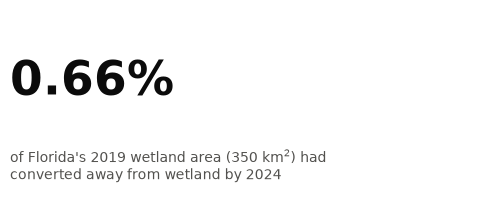

In [13]:
total_pixels = len(sample)
converted_pixels = int((sample["label"] != 0).sum())
converted_area_km2 = converted_pixels * PIXEL_AREA_KM2
converted_pct = 100 * converted_pixels / total_pixels

fig, ax = plt.subplots(figsize=(5, 2.2))
ax.axis("off")
ax.text(0.0, 0.62, f"{converted_pct:.2f}%", fontsize=34, fontweight="bold", color="#0b0b0b", ha="left", va="center")
ax.text(0.0, 0.18, f"of Florida's {YEAR_BASE} wetland area ({converted_area_km2:,.0f} km$^2$) had\nconverted away from wetland by {YEAR_TARGET}", fontsize=10, color="#52514e", ha="left", va="center")
fig.tight_layout()
plt.show()

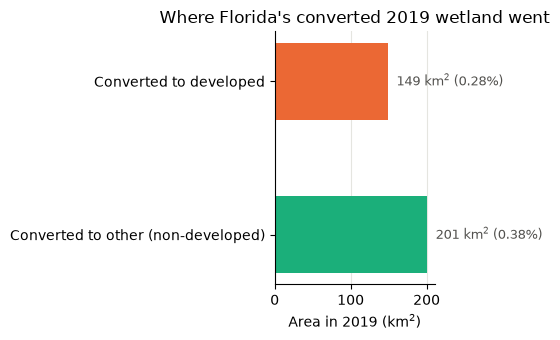

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
order = [1, 2]
bars = ax.barh(
    [LABEL_NAMES[i] for i in order],
    [counts.loc[LABEL_NAMES[i], "area_km2"] for i in order],
    color=[LABEL_COLORS[i] for i in order],
    height=0.5,
)
ax.set_xlabel("Area in 2019 (km$^2$)")
ax.set_title(f"Where Florida's converted {YEAR_BASE} wetland went")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.invert_yaxis()
for bar, i in zip(bars, order):
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f} km$^2$ ({counts.loc[LABEL_NAMES[i], 'pct_of_2019_wetland']:.2f}%)",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(6, 0), textcoords="offset points",
        ha="left", va="center", fontsize=9, color="#52514e",
    )
fig.tight_layout()
plt.show()

## Step 10: Maps

Every map below renders a downsampled grid rather than the full resolution
array, just to keep figure rendering fast. All statistics above were computed
at full 30 m resolution. For the categorical maps (a through c, and the label
map), naively striding every Nth pixel would make rare classes like
"converted to developed" (0.28% of the sample) all but disappear, since a
real pixel could easily fall on a skipped row or column. Instead,
`downsample_any` reduces each `MAP_DOWNSAMPLE x MAP_DOWNSAMPLE` block to its
highest priority value (any positive pixel anywhere in the block survives),
so rare classes stay visible, at the cost of exaggerating their footprint a
little. The distance map (d) is a smooth continuous field, so plain striding
(`downsample_stride`) is representative there and doesn't have this problem.

In [15]:
def downsample_stride(arr):
    return arr[::MAP_DOWNSAMPLE, ::MAP_DOWNSAMPLE]

def downsample_any(arr):
    '''Reduce each MAP_DOWNSAMPLE block using the max, so any rare or high
    priority value in a block survives. Plain striding would drop most
    isolated pixels of a rare class.'''
    h, w = arr.shape
    h_trim = (h // MAP_DOWNSAMPLE) * MAP_DOWNSAMPLE
    w_trim = (w // MAP_DOWNSAMPLE) * MAP_DOWNSAMPLE
    trimmed = arr[:h_trim, :w_trim]
    reshaped = trimmed.reshape(h_trim // MAP_DOWNSAMPLE, MAP_DOWNSAMPLE, w_trim // MAP_DOWNSAMPLE, MAP_DOWNSAMPLE)
    return reshaped.max(axis=(1, 3))

def plot_extent_pair(mask_base, mask_target, color, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), sharex=True, sharey=True)
    cmap = ListedColormap(["#ffffff", color])
    for ax, mask, year in zip(axes, [mask_base, mask_target], [YEAR_BASE, YEAR_TARGET]):
        ax.imshow(downsample_any(mask), cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
        area_km2 = int(mask.sum()) * PIXEL_AREA_KM2
        ax.set_title(f"{year}  ({area_km2:,.0f} km$^2$)")
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()

### a) Wetland extent: 2019 versus 2024

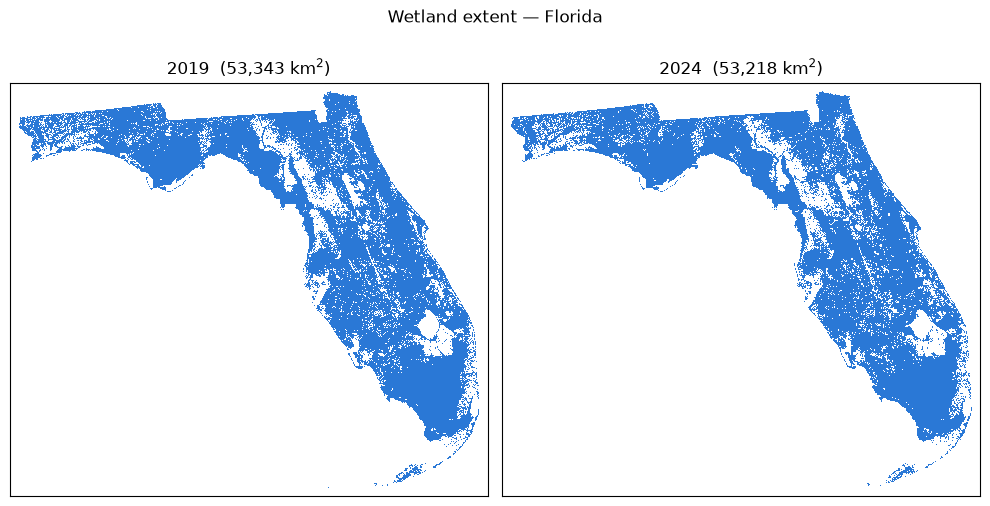

In [16]:
plot_extent_pair(wetland_2019_mask, wetland_2024_mask, LABEL_COLORS[0], "Wetland extent, Florida")

### b) Developed extent: 2019 versus 2024

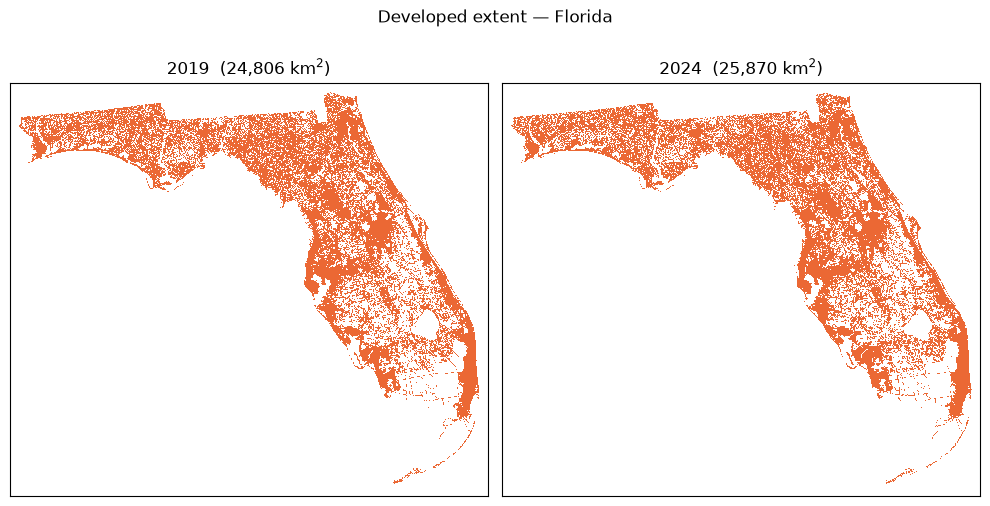

In [17]:
plot_extent_pair(developed_2019_mask, developed_2024_mask, DEVELOPED_COLOR, "Developed extent, Florida")

### c) Wetland (2019) becomes developed (2024)

2019 wetland that stayed wetland, or converted to something other than
developed, is shown faded for context. Wetland that specifically converted
to a developed class by 2024 is highlighted in orange.

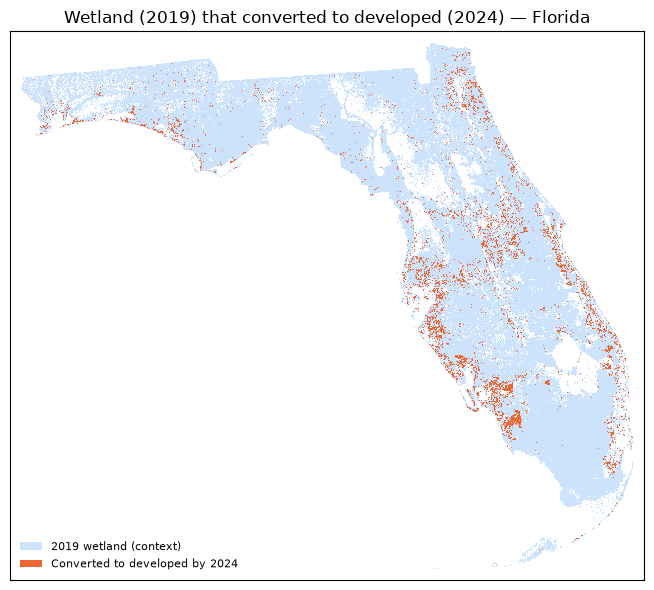

In [18]:
conversion_grid = np.zeros(wetland_2019_mask.shape, dtype=np.int8)
conversion_grid[wetland_2019_mask] = 1                                # context
conversion_grid[wetland_2019_mask & developed_2024_mask] = 2          # highlighted

cmap = ListedColormap(["#ffffff", CONTEXT_COLOR, DEVELOPED_COLOR])
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(downsample_any(conversion_grid), cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
ax.set_title(f"Wetland ({YEAR_BASE}) that converted to developed ({YEAR_TARGET}), Florida")
ax.set_xticks([]); ax.set_yticks([])
legend_handles = [
    Patch(facecolor=CONTEXT_COLOR, label=f"{YEAR_BASE} wetland (context)"),
    Patch(facecolor=DEVELOPED_COLOR, label=f"Converted to developed by {YEAR_TARGET}"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

### Sample and label map (all three outcomes)

The same style of map as (c), but showing all three 2024 outcomes for the
full 2019 wetland sample. This is the spatial view of the labeled dataset
saved in Step 7.

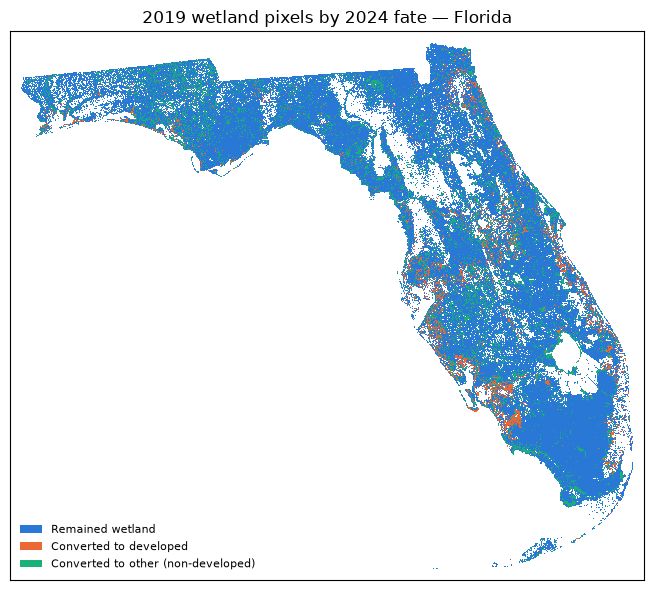

In [19]:
label_grid = np.full(wetland_2019_mask.shape, -1, dtype=np.int8)
label_grid[wetland_2019_mask & wetland_2024_mask] = 0
label_grid[wetland_2019_mask & developed_2024_mask] = 1
other_mask = wetland_2019_mask & ~wetland_2024_mask & ~developed_2024_mask
label_grid[other_mask] = 2

cmap = ListedColormap(["#ffffff"] + [LABEL_COLORS[i] for i in (0, 1, 2)])
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(downsample_any(label_grid) + 1, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
ax.set_title(f"2019 wetland pixels by {YEAR_TARGET} fate, Florida")
ax.set_xticks([]); ax.set_yticks([])
legend_handles = [Patch(facecolor=LABEL_COLORS[i], label=LABEL_NAMES[i]) for i in (0, 1, 2)]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

### d) Distance from each 2019 wetland pixel to the nearest 2019 developed pixel

This uses a sequential, one hue encoding, since it's a continuous magnitude
rather than a category. Light means close to development, dark means far.
Only 2019 wetland pixels are colored. Everything else is left white.

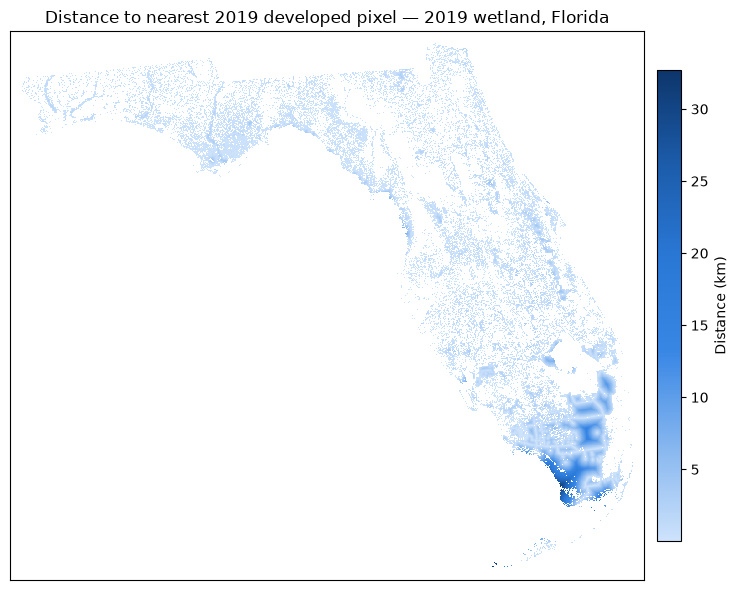

In [20]:
dist_masked = np.where(wetland_2019_mask, dist_to_developed_2019 / 1000.0, np.nan)  # km

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(downsample_stride(dist_masked), cmap=DISTANCE_CMAP, interpolation="nearest")
ax.set_title(f"Distance to nearest {YEAR_BASE} developed pixel: {YEAR_BASE} wetland, Florida")
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Distance (km)")
fig.tight_layout()
plt.show()

## Step 11: Spatial structure of conversion

Three cuts through the labeled sample that get at why some wetland converts
and some doesn't: proximity to existing development, the wetland type
itself, and, for the pixels that do convert to developed, what kind of
development they become.

### a) Distance to development: converters versus non converters

"Converters" here means pixels labeled `Converted to developed` (`label == 1`,
0.28% of the sample). "Non converters" is everything else, overwhelmingly
`Remained wetland`, plus the small `Converted to other` slice. Distance is
plotted on a log$_{10}(d+1)$ axis, since it spans from 0 to over 100 km, and a
linear axis would compress the near field detail that's actually the point
of this plot.

For 2024 specifically: a converter's own distance to 2024 development is
about 0 by construction (see Step 5's note). That spike at the origin is the
signature of conversion, not an artifact to explain away.

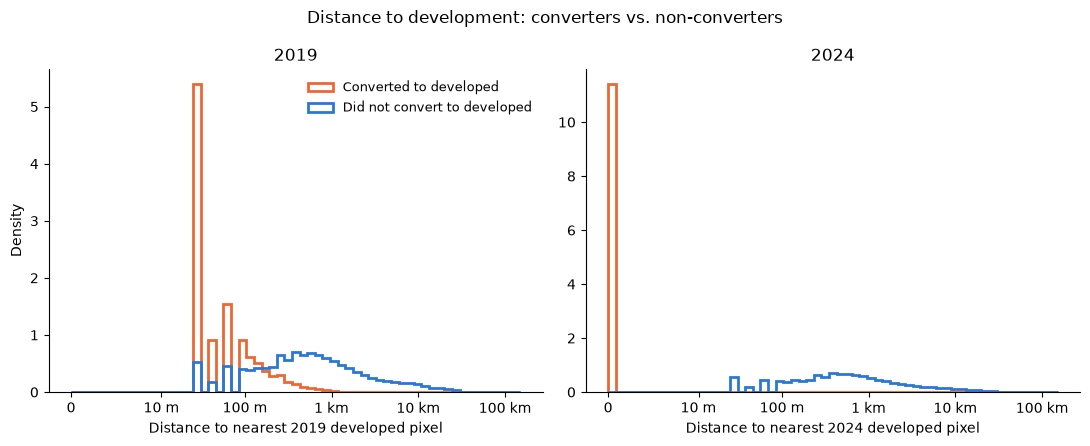

In [21]:
is_converter = sample["label"] == 1
groups = [
    ("Converted to developed", is_converter, LABEL_COLORS[1]),
    ("Did not convert to developed", ~is_converter, NON_CONVERTER_COLOR),
]

def log1p10(x):
    return np.log10(np.asarray(x, dtype=np.float64) + 1.0)

T_MAX = log1p10(150_000)
bins = np.linspace(0, T_MAX, 60)
tick_vals = [0, 10, 100, 1_000, 10_000, 100_000]
tick_pos = log1p10(tick_vals)
tick_labels = ["0", "10 m", "100 m", "1 km", "10 km", "100 km"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, year in zip(axes, ["dist_to_developed_2019_m", "dist_to_developed_2024_m"], [YEAR_BASE, YEAR_TARGET]):
    for name, mask, color in groups:
        ax.hist(log1p10(sample.loc[mask, col]), bins=bins, density=True,
                histtype="step", linewidth=2, color=color, label=name)
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
    ax.set_xlabel(f"Distance to nearest {year} developed pixel")
    ax.set_title(str(year))
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=9, loc="upper right")
fig.suptitle("Distance to development: converters versus non converters")
fig.tight_layout()
plt.show()

A numeric complement to the shapes above:

In [22]:
dist_summary = (
    sample.assign(group=np.where(is_converter, "Converted to developed", "Did not convert to developed"))
    .groupby("group")[["dist_to_developed_2019_m", "dist_to_developed_2024_m"]]
    .median()
    .round(0)
)
dist_summary.columns = [f"median dist. to {YEAR_BASE} developed (m)", f"median dist. to {YEAR_TARGET} developed (m)"]
dist_summary

,median dist. to 2019 developed (m),median dist. to 2024 developed (m)
group,,
Converted to developed,42.0,0.0
Did not convert to developed,510.0,495.0


### b) Conversion rate by initial wetland type

The two 2019 wetland classes convert at different rates and toward different
outcomes. `Remained wetland` dominates both (over 99%, per Step 9), so, for
the same reason as Step 9, the chart below isolates just the two conversion
outcomes instead of compressing them under a bar that's 99% tall.

In [23]:
rate_by_type = (
    sample.groupby("lc_2019", observed=True)["label"]
    .value_counts(normalize=True)
    .rename("rate")
    .mul(100)
    .unstack()
    .rename(columns=LABEL_NAMES)
    .rename(index=WETLAND_CLASS_NAMES)
    .loc[:, [LABEL_NAMES[1], LABEL_NAMES[2]]]
)
rate_by_type

label,Converted to developed,Converted to other (non-developed)
lc_2019,,
Woody Wetlands,0.327852,0.217651
Emergent Herbaceous Wetlands,0.157382,0.783216


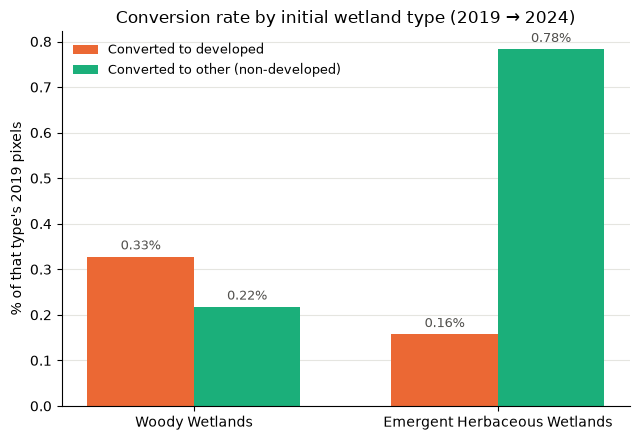

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
wetland_types = rate_by_type.index.tolist()
x = np.arange(len(wetland_types))
width = 0.35
for i, outcome in enumerate((1, 2)):
    values = rate_by_type[LABEL_NAMES[outcome]].to_numpy()
    bars = ax.bar(x + (i - 0.5) * width, values, width, color=LABEL_COLORS[outcome], label=LABEL_NAMES[outcome])
    for bar, v in zip(bars, values):
        ax.annotate(f"{v:.2f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, color="#52514e")
ax.set_xticks(x); ax.set_xticklabels(wetland_types)
ax.set_ylabel(f"% of that type's {YEAR_BASE} pixels")
ax.set_title(f"Conversion rate by initial wetland type ({YEAR_BASE} to {YEAR_TARGET})")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e5e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### b, continued: what did "converted to other" actually become?

`Converted to other` (`label == 2`) isn't one destination. It's a mix of
every NLCD class that is not wetland and not developed. Ranked by pixel
count across both wetland types combined:

In [25]:
other_lc_counts = (
    sample.loc[sample["label"] == 2, "lc_2024"]
    .value_counts()
    .rename("pixels")
    .to_frame()
)
other_lc_counts["pct_of_other"] = 100 * other_lc_counts["pixels"] / other_lc_counts["pixels"].sum()
other_lc_counts.index = [OTHER_CLASS_NAMES.get(c, str(c)) for c in other_lc_counts.index]

top3_codes = sample.loc[sample["label"] == 2, "lc_2024"].value_counts().index[:3].tolist()
top3_share = other_lc_counts["pct_of_other"].iloc[:3].sum()
print(f"Top 3 destinations ({', '.join(OTHER_CLASS_NAMES[c] for c in top3_codes)}) "
      f"account for {top3_share:.1f}% of all 'Converted to other' pixels.")
other_lc_counts

Top 3 destinations (Open Water, Pasture/Hay, Barren Land) account for 80.5% of all 'Converted to other' pixels.


,pixels,pct_of_other
Open Water,126191,56.521486
Pasture/Hay,27372,12.260035
Barren Land,26067,11.675520
Grassland/Herbaceous,18934,8.480619
Evergreen Forest,13876,6.215119
Cultivated Crops,8742,3.915579
Shrub/Scrub,2070,0.927162
Mixed Forest,9,0.004031
Deciduous Forest,1,0.000448


The top 3 land uses, `Open Water`, `Pasture/Hay`, and `Barren Land`, split
very differently by wetland type. Same convention as (b) above: rate equals
percent of that wetland type's own 2019 pixel count, so the two wetland
types are directly comparable even though they have very different sample
sizes.

In [26]:
totals_by_type = sample.groupby("lc_2019", observed=True).size()

top3_breakdown = (
    sample.loc[sample["lc_2024"].isin(top3_codes) & (sample["label"] == 2)]
    .groupby(["lc_2019", "lc_2024"], observed=True)
    .size()
    .rename("pixels")
    .reset_index()
)
top3_breakdown["pct_of_2019_wetland"] = 100 * top3_breakdown["pixels"] / top3_breakdown["lc_2019"].map(totals_by_type)
top3_breakdown["wetland_type"] = top3_breakdown["lc_2019"].map(WETLAND_CLASS_NAMES)
top3_breakdown["destination"] = top3_breakdown["lc_2024"].map(OTHER_CLASS_NAMES)

top3_pivot = top3_breakdown.pivot(index="wetland_type", columns="destination", values="pct_of_2019_wetland")
top3_pivot = top3_pivot.reindex(columns=[OTHER_CLASS_NAMES[c] for c in top3_codes])
top3_pivot = top3_pivot.reindex(index=rate_by_type.index)  # match panel (b)'s wetland type order
top3_pivot

destination,Open Water,Pasture/Hay,Barren Land
lc_2019,,,
Woody Wetlands,0.037611,0.051352,0.032563
Emergent Herbaceous Wetlands,0.661012,0.032965,0.073165


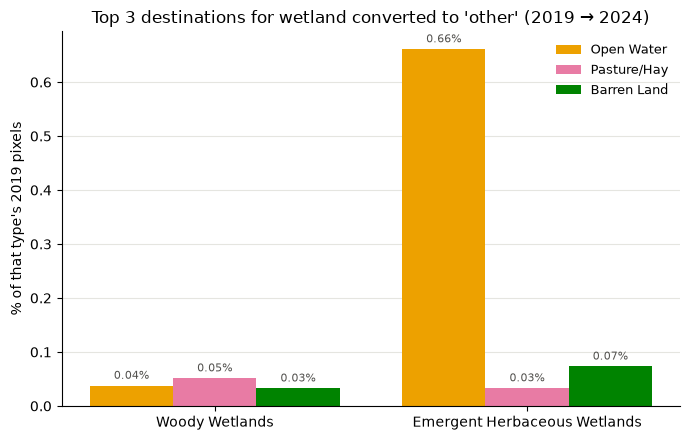

In [27]:
OTHER_COLORS = ["#eda100", "#e87ba4", "#008300"]  # categorical slots 4 to 6 (yellow / magenta / green)

fig, ax = plt.subplots(figsize=(7, 4.5))
wetland_types = top3_pivot.index.tolist()
x = np.arange(len(wetland_types))
n_dest = len(top3_pivot.columns)
width = 0.8 / n_dest
for i, dest in enumerate(top3_pivot.columns):
    values = top3_pivot[dest].to_numpy()
    offset = (i - (n_dest - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, color=OTHER_COLORS[i], label=dest)
    for bar, v in zip(bars, values):
        if np.isnan(v):
            continue
        ax.annotate(f"{v:.2f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8, color="#52514e")
ax.set_xticks(x); ax.set_xticklabels(wetland_types)
ax.set_ylabel(f"% of that type's {YEAR_BASE} pixels")
ax.set_title(f"Top 3 destinations for wetland converted to 'other' ({YEAR_BASE} to {YEAR_TARGET})")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e5e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### c) Conversion rate by type of development

Among the wetland that did convert to developed, which developed subtype did
it become? These four classes form an intensity order, from Open Space to
High Intensity, so they're encoded as a single hue sequential ramp rather
than distinct categorical colors.

In [28]:
developed_rates = (
    sample.loc[sample["label"] == 1, "lc_2024"]
    .value_counts()
    .reindex(list(DEVELOPED_CLASSES), fill_value=0)
    .rename("pixels")
    .to_frame()
)
developed_rates["area_km2"] = developed_rates["pixels"] * PIXEL_AREA_KM2
developed_rates[f"pct_of_{YEAR_BASE}_wetland"] = 100 * developed_rates["pixels"] / len(sample)
developed_rates.index = [DEVELOPED_CLASS_NAMES[c] for c in developed_rates.index]
developed_rates

,pixels,area_km2,pct_of_2019_wetland
Open Space,66529,59.8761,0.112247
Low Intensity,53411,48.0699,0.090114
Medium Intensity,40066,36.0594,0.067599
High Intensity,5902,5.3118,0.009958


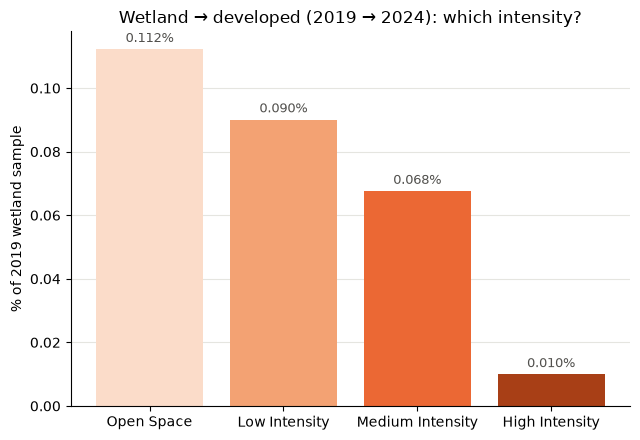

In [29]:
ORANGE_SEQ = ["#fbdcc9", "#f3a273", "#eb6834", "#a83f16"]  # light to dark, single hue (intensity order)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
labels = developed_rates.index.tolist()
values = developed_rates[f"pct_of_{YEAR_BASE}_wetland"].to_numpy()
bars = ax.bar(labels, values, color=ORANGE_SEQ)
for bar, v in zip(bars, values):
    ax.annotate(f"{v:.3f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, color="#52514e")
ax.set_ylabel(f"% of {YEAR_BASE} wetland sample")
ax.set_title(f"Wetland becomes developed ({YEAR_BASE} to {YEAR_TARGET}): which intensity?")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e5e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()